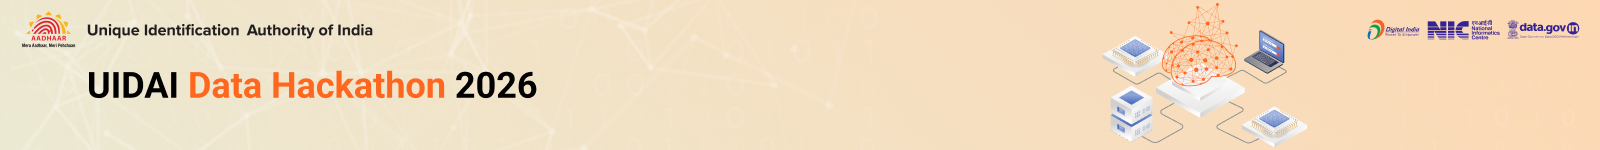

In [ ]:
!pip install -q thefuzz[speedup]

from google.colab import drive
import pandas as pd
import numpy as np
import re
from thefuzz import process, fuzz
from functools import lru_cache


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:00


In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


Extract UIDAI ZIP files from Drive

In [ ]:
import os

ZIP_PATH = "/content/drive/MyDrive/UIDAI dataset/*.zip"
EXTRACT_PATH = "/content/uidai_data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

!unzip -oq "{ZIP_PATH}" -d "{EXTRACT_PATH}"

print("ZIPs extracted to:", EXTRACT_PATH)



3 archives were successfully processed.
ZIPs extracted to: /content/uidai_data


Loading Master Dataset

In [ ]:
MASTER_PATH = "/content/drive/MyDrive/UIDAI dataset/Master_Dataset.csv"
df_master = pd.read_csv(MASTER_PATH)

print(" Master loaded:", df_master.shape)
df_master.head()


 Master loaded: (165627, 3)


,pincode,district,state
0,504273,KUMURAM BHEEM ASIFABAD,TELANGANA
1,504299,KUMURAM BHEEM ASIFABAD,TELANGANA
2,504299,KUMURAM BHEEM ASIFABAD,TELANGANA
3,504296,KUMURAM BHEEM ASIFABAD,TELANGANA
4,504296,KUMURAM BHEEM ASIFABAD,TELANGANA


Preprocessing

In [ ]:
def preprocess_text(text):
    if pd.isna(text):
        return None
    text = str(text).strip().upper()
    text = text.replace("&", "AND")  # mandatory
    text = re.sub(r"[^A-Z0-9\s]", "", text)  # removes *, -, / etc.
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# State rule-based correction (DNHDD, WB, Puducherry + protect Andaman)
DNHDD = "THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU"
WB = "WEST BENGAL"
PY = "PUDUCHERRY"
ANDAMAN = "ANDAMAN AND NICOBAR ISLANDS"

def apply_state_rules(state):
    if not state:
        return state

    # protect Andaman (no confusion)
    if state == ANDAMAN:
        return state

    # West Bengal spellings
    if state in ["WESTBENGAL", "WEST BANGAL", "WESTBANGAL", "W BENGAL"]:
        return WB

    # Puducherry spellings
    if state in ["PONDICHERRY", "PONDICHERY"]:
        return PY

    # DNHDD rules (catch partial names and misspellings)
    # Important: match by whole words to avoid Andaman substring confusion
    tokens = set(state.split())
    if (
        "DIU" in tokens or
        "DAMAN" in tokens or
        "DADRA" in tokens or
        ("NAGAR" in tokens and "HAVELI" in tokens) or
        ("DADRA" in tokens and "HAVELI" in tokens)
    ):
        return DNHDD

    return state

In [ ]:
#Cleaning Master Dataset
def clean_master(df_master):
    df = df_master.copy()
    df.columns = df.columns.str.strip().str.lower()

    # force expected columns
    df = df[["pincode", "district", "state"]].copy()

    # preprocess
    df["state"] = df["state"].apply(preprocess_text).apply(apply_state_rules)
    df["district"] = df["district"].apply(preprocess_text)
    df["pincode"] = df["pincode"].astype(str).str.strip()

    # remove empty/na
    df.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan}, inplace=True)
    df.dropna(subset=["pincode", "district", "state"], inplace=True)

    # remove numeric-only district like 100000
    df = df[~df["district"].str.match(r"^\d+$", na=False)]

    # keep valid 6-digit pincode only
    df = df[df["pincode"].str.match(r"^\d{6}$", na=False)]

    # remove duplicates
    df = df.drop_duplicates().reset_index(drop=True)

    return df

#  run this after loading df_master
df_master = clean_master(df_master)
OUT_DIR = "/content/drive/MyDrive/UIDAI dataset/"

# Save cleaned master
CLEAN_MASTER_PATH = OUT_DIR + "CLEANED_master.csv"
df_master.to_csv(CLEAN_MASTER_PATH, index=False)

print(" Cleaned master exported to Drive:", CLEAN_MASTER_PATH)
print(" Cleaned master shape:", df_master.shape)
df_master.head()

print(" Cleaned MASTER shape:", df_master.shape)
df_master.head()

# Building master lists/maps
valid_states = df_master["state"].unique().tolist()

state_to_districts = (
    df_master.groupby("state")["district"]
    .unique()
    .to_dict()
)

valid_pincodes = set(df_master["pincode"].astype(str))
print(valid_states)
print(" Master reference created.")



 Cleaned master exported to Drive: /content/drive/MyDrive/UIDAI dataset/CLEANED_master.csv
 Cleaned master shape: (20824, 3)
 Cleaned MASTER shape: (20824, 3)
['TELANGANA', 'ANDHRA PRADESH', 'ASSAM', 'BIHAR', 'CHHATTISGARH', 'MEGHALAYA', 'JHARKHAND', 'KARNATAKA', 'HIMACHAL PRADESH', 'JAMMU AND KASHMIR', 'LADAKH', 'GUJARAT', 'THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU', 'HARYANA', 'DELHI', 'MAHARASHTRA', 'KERALA', 'MANIPUR', 'MIZORAM', 'NAGALAND', 'PUDUCHERRY', 'MADHYA PRADESH', 'GOA', 'PUNJAB', 'RAJASTHAN', 'ODISHA', 'TRIPURA', 'ARUNACHAL PRADESH', 'TAMIL NADU', 'CHANDIGARH', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL', 'ANDAMAN AND NICOBAR ISLANDS', 'SIKKIM', 'LAKSHADWEEP']
 Master reference created.


In [ ]:
#Generic fuzzy correction function (Threshold 70)
FUZZY_THRESHOLD = 70  # change to 60 if needed

def validate_and_correct(value, master_list, threshold=FUZZY_THRESHOLD):
    if not value:
        return None, 0, "NULL"

    # exact
    if value in master_list:
        return value, 100, "EXACT"

    # fuzzy
    match, score = process.extractOne(value, master_list, scorer=fuzz.token_set_ratio)
    if score >= threshold:
        return match, score, "FUZZY"

    return None, score, "INVALID"


In [ ]:
#cleaning the dataset

def clean_uidai_dataset(df, df_name="dataset"):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    # preprocess
    df["state"] = df["state"].apply(preprocess_text).apply(apply_state_rules)
    df["district"] = df["district"].apply(preprocess_text)
    df["pincode"] = df["pincode"].astype(str).str.strip()

    # remove numeric district junk
    df = df[~df["district"].str.match(r"^\d+$", na=False)].copy()

    # ---------- STATE CLEAN (cached) ----------
    @lru_cache(maxsize=None)
    def fast_state_clean(x):
        return validate_and_correct(x, tuple(valid_states))

    state_results = df["state"].map(fast_state_clean)
    df[["cleaned_state", "state_score", "state_flag"]] = pd.DataFrame(
        state_results.tolist(), index=df.index
    )

    # ---------- DISTRICT CLEAN (state-aware + cached) ----------
    @lru_cache(maxsize=None)
    def fast_district_clean(cleaned_state, district):
        if not cleaned_state or cleaned_state not in state_to_districts:
            return None, 0, "STATE_INVALID"
        return validate_and_correct(district, tuple(state_to_districts[cleaned_state]))

    district_results = df.apply(lambda r: fast_district_clean(r["cleaned_state"], r["district"]), axis=1)
    df[["cleaned_district", "district_score", "district_flag"]] = pd.DataFrame(
        district_results.tolist(), index=df.index
    )

    # ---------- PINCODE VALID ----------
    df["pincode_valid"] = df["pincode"].astype(str).isin(valid_pincodes)

    # ---------- STRICT REJECTION RULE ----------
    df["is_clean"] = (
        df["cleaned_state"].notna() &
        df["cleaned_district"].notna() &
        df["pincode_valid"].eq(True)
    )

    cleaned_df = df[df["is_clean"]].copy()
    rejected_df = df[~df["is_clean"]].copy()

    # summary
    total = len(df)
    clean_n = len(cleaned_df)
    rej_n = len(rejected_df)

    print(f"\n {df_name} cleaning summary")
    print(f"Total: {total}")
    print(f"Cleaned: {clean_n} ({(clean_n/total)*100:.2f}%)")
    print(f"Rejected: {rej_n} ({(rej_n/total)*100:.2f}%)")

    return cleaned_df, rejected_df


In [ ]:
# ---------------- LOAD UIDAI DATASETS ---------------- #

def load_uidai_folder(folder_name):
    folder_path = os.path.join(EXTRACT_PATH, folder_name)
    csv_files = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.endswith(".csv")
    ]
    if not csv_files:
        raise ValueError(f"No CSVs found in {folder_path}")

    return pd.concat(
        (pd.read_csv(f, low_memory=False) for f in csv_files),
        ignore_index=True
    )

df_enrolment   = load_uidai_folder("api_data_aadhar_enrolment")
df_demographic = load_uidai_folder("api_data_aadhar_demographic")
df_biometric   = load_uidai_folder("api_data_aadhar_biometric")

print("Loaded:")
print("Enrolment:", df_enrolment.shape)
print("Demographic:", df_demographic.shape)
print("Biometric:", df_biometric.shape)


Loaded:
Enrolment: (1006029, 7)
Demographic: (2071700, 6)
Biometric: (1861108, 6)


In [ ]:
print(
    "df_enrolment:", "YES" if 'df_enrolment' in globals() else "NO",
    "| df_demographic:", "YES" if 'df_demographic' in globals() else "NO",
    "| df_biometric:", "YES" if 'df_biometric' in globals() else "NO"
)


df_enrolment: YES | df_demographic: YES | df_biometric: YES


In [ ]:
cleaned_enrol, rejected_enrol = clean_uidai_dataset(df_enrolment, "ENROLMENT")
cleaned_demo, rejected_demo  = clean_uidai_dataset(df_demographic, "DEMOGRAPHIC")
cleaned_bio, rejected_bio    = clean_uidai_dataset(df_biometric, "BIOMETRIC")

OUT_DIR = "/content/drive/MyDrive/UIDAI dataset/"

cleaned_enrol.to_csv(OUT_DIR + "CLEANED_enrolment.csv", index=False)
rejected_enrol.to_csv(OUT_DIR + "REJECTED_enrolment.csv", index=False)

cleaned_demo.to_csv(OUT_DIR + "CLEANED_demographic.csv", index=False)
rejected_demo.to_csv(OUT_DIR + "REJECTED_demographic.csv", index=False)

cleaned_bio.to_csv(OUT_DIR + "CLEANED_biometric.csv", index=False)
rejected_bio.to_csv(OUT_DIR + "REJECTED_biometric.csv", index=False)

print("All exports done:", OUT_DIR)




 ENROLMENT cleaning summary
Total: 1006007
Cleaned: 929699 (92.41%)
Rejected: 76308 (7.59%)

 DEMOGRAPHIC cleaning summary
Total: 2071698
Cleaned: 1856285 (89.60%)
Rejected: 215413 (10.40%)

 BIOMETRIC cleaning summary
Total: 1861108
Cleaned: 1679004 (90.22%)
Rejected: 182104 (9.78%)
All exports done: /content/drive/MyDrive/UIDAI dataset/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pinteresty pastel theme
sns.set_theme(style="whitegrid")
PALETTE = ["#FFC8DD", "#CDB4DB", "#A2D2FF", "#BDE0FE", "#FFAFCC"]


In [ ]:
for df in [cleaned_enrol, cleaned_demo, cleaned_bio]:
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df["year_month"] = df["date"].dt.to_period("M").astype(str)


In [ ]:
# detect age cols safely
age_cols = [c for c in cleaned_enrol.columns if c.startswith("age_")]
if len(age_cols) == 0:
    raise ValueError(" Enrolment dataset does not contain age_* columns (age_0_5 etc.)")

cleaned_enrol["total_enrolments"] = cleaned_enrol[age_cols].sum(axis=1)

monthly_ops = (
    cleaned_enrol
    .groupby(["cleaned_state", "cleaned_district", "year_month"], as_index=False)
    .agg(total_enrolments=("total_enrolments", "sum"))
)

monthly_demo = (
    cleaned_demo
    .groupby(["cleaned_state", "cleaned_district", "year_month"], as_index=False)
    .sum(numeric_only=True)
)

monthly_bio = (
    cleaned_bio
    .groupby(["cleaned_state", "cleaned_district", "year_month"], as_index=False)
    .sum(numeric_only=True)
)

ops_df = (
    monthly_ops
    .merge(monthly_demo, on=["cleaned_state", "cleaned_district", "year_month"], how="left")
    .merge(monthly_bio, on=["cleaned_state", "cleaned_district", "year_month"], how="left")
)

ops_df.fillna(0, inplace=True)

# total updates
demo_cols = [c for c in ops_df.columns if c.startswith("demo_")]
bio_cols  = [c for c in ops_df.columns if c.startswith("bio_")]

ops_df["total_updates"] = ops_df[demo_cols].sum(axis=1) + ops_df[bio_cols].sum(axis=1)
ops_df["total_load"] = ops_df["total_enrolments"] + ops_df["total_updates"]

ops_df = ops_df.sort_values(["cleaned_state", "cleaned_district", "year_month"]).reset_index(drop=True)

print(" ops_df created:", ops_df.shape)
ops_df.head()


 ops_df created: (3944, 18)


,cleaned_state,cleaned_district,year_month,total_enrolments,demo_age_5_17,demo_age_17_,state_score_x,district_score_x,pincode_valid_x,is_clean_x,bio_age_5_17,bio_age_17_,state_score_y,district_score_y,pincode_valid_y,is_clean_y,total_updates,total_load
0,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-09,48,2.0,149.0,3300.0,3069.0,33.0,33.0,94.0,155.0,5700.0,5308.0,57.0,57.0,400.0,448.0
1,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-10,10,9.0,50.0,1900.0,1767.0,19.0,19.0,36.0,63.0,3100.0,2883.0,31.0,31.0,158.0,168.0
2,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-11,12,5.0,109.0,4100.0,3841.0,41.0,41.0,132.0,58.0,4200.0,3906.0,42.0,42.0,304.0,316.0
3,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-12,6,10.0,65.0,3700.0,3441.0,37.0,37.0,212.0,54.0,5600.0,5215.0,56.0,56.0,341.0,347.0
4,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN,2025-09,40,10.0,240.0,6900.0,6900.0,69.0,69.0,559.0,187.0,8600.0,8600.0,86.0,86.0,996.0,1036.0


In [ ]:
# previous load
ops_df["prev_load"] = ops_df.groupby(["cleaned_state","cleaned_district"])["total_load"].shift(1)

# growth %
ops_df["load_growth_pct"] = ((ops_df["total_load"] - ops_df["prev_load"]) / (ops_df["prev_load"] + 1)) * 100

# 3-month moving avg
ops_df["load_ma3"] = ops_df.groupby(["cleaned_state","cleaned_district"])["total_load"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

ops_df["deviation_from_ma3"] = ops_df["total_load"] - ops_df["load_ma3"]


In [ ]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

ops_df["load_norm"] = minmax(ops_df["total_load"])
ops_df["growth_norm"] = minmax(ops_df["load_growth_pct"].clip(lower=0))
ops_df["dev_norm"] = minmax(ops_df["deviation_from_ma3"].clip(lower=0))

ops_df["stress_index"] = (
    0.5 * ops_df["load_norm"] +
    0.3 * ops_df["growth_norm"] +
    0.2 * ops_df["dev_norm"]
) * 100

ops_df["stress_level"] = pd.cut(
    ops_df["stress_index"],
    bins=[-1, 30, 60, 100],
    labels=["LOW", "MEDIUM", "HIGH"]
)

ops_df[["cleaned_state","cleaned_district","year_month","stress_index","stress_level"]].head()


,cleaned_state,cleaned_district,year_month,stress_index,stress_level
0,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-09,NaN,NaN
1,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-10,0.043441,LOW
2,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-11,0.606731,LOW
3,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2025-12,0.167771,LOW
4,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN,2025-09,NaN,NaN


In [ ]:
stress_thresh = ops_df["stress_index"].quantile(0.90)
growth_thresh = ops_df["load_growth_pct"].quantile(0.90)
load_thresh   = ops_df["total_load"].quantile(0.90)

ops_df["early_warning_flag"] = (
    (ops_df["stress_index"] >= stress_thresh) &
    (ops_df["load_growth_pct"] >= growth_thresh) &
    (ops_df["total_load"] >= load_thresh)
)

ops_df["warning_level"] = np.select(
    [ops_df["early_warning_flag"], ops_df["stress_level"].eq("HIGH")],
    ["RED ALERT", "ORANGE ALERT"],
    default="NORMAL"
)


In [ ]:
CENTER_CAPACITY = 20000  # assumption (can mention in report)

ops_df["centers_required_est"] = np.ceil(ops_df["total_load"] / CENTER_CAPACITY)

ops_df["resource_action"] = np.select(
    [
        ops_df["warning_level"].eq("RED ALERT"),
        ops_df["warning_level"].eq("ORANGE ALERT"),
        ops_df["stress_level"].eq("MEDIUM")
    ],
    [
        "Add temporary centers + staff",
        "Add permanent centers + optimize staffing",
        "Monitor + awareness campaign"
    ],
    default="No action"
)


In [ ]:
ops_df["load_zscore"] = (
    (ops_df["total_load"] - ops_df["total_load"].mean()) /
    (ops_df["total_load"].std() + 1e-9)
)

ops_df["anomaly_flag"] = ops_df["load_zscore"].abs() > 3


Chart 1 — Stress Index Trend (Top 10 Districts)








/tmp/ipython-input-1466646768.py:12: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=plot_df, x="year_month", y="stress_index", hue="cleaned_district", palette=PALETTE)


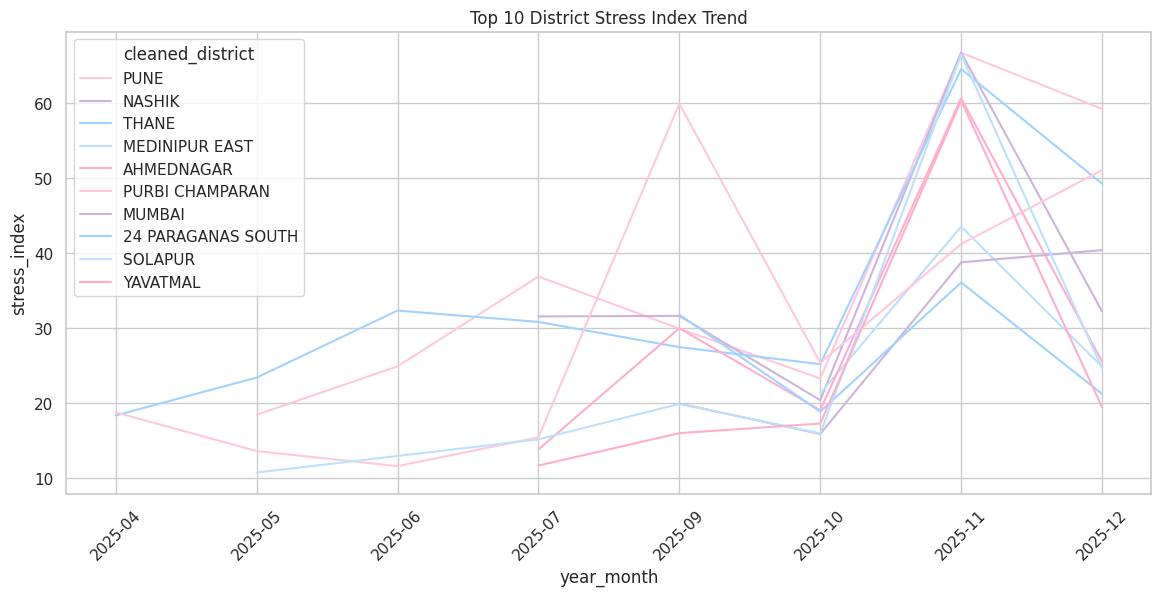

In [ ]:
top10 = (
    ops_df.groupby(["cleaned_state","cleaned_district"])["stress_index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = ops_df.set_index(["cleaned_state","cleaned_district"]).loc[top10].reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=plot_df, x="year_month", y="stress_index", hue="cleaned_district", palette=PALETTE)
plt.xticks(rotation=45)
plt.title("Top 10 District Stress Index Trend")
plt.show()


* The stress index changes month-by-month across districts, so workload is not
constant.

* Most districts show a sharp increase in stress in the later months.

* November 2025 shows the highest peak stress for almost all top districts, indicating maximum overload.

* Districts like Pune, Thane, and Mumbai show consistently high stress, meaning they may require permanent capacity improvements.

* Some districts show sudden spikes rather than continuous stress, suggesting temporary demand surges.

* After peak months, stress reduces again, meaning resource planning should be dynamic (seasonal staffing/centres).


The chart shows how stress levels vary across the top ten districts over time, reflecting changes in Aadhaar enrolment and update workload. A clear rise in stress is observed in the later months, with November 2025 emerging as the peak overload period for most districts. Some districts remain consistently stressed throughout multiple months, indicating long-term infrastructure or staffing gaps, while others experience short-term spikes that may be linked to temporary surges in demand. Overall, the trend highlights the need for both permanent resource strengthening in high-burden districts and short-term surge planning during peak months.

Chart 2 — Heatmap (District × Month Stress)

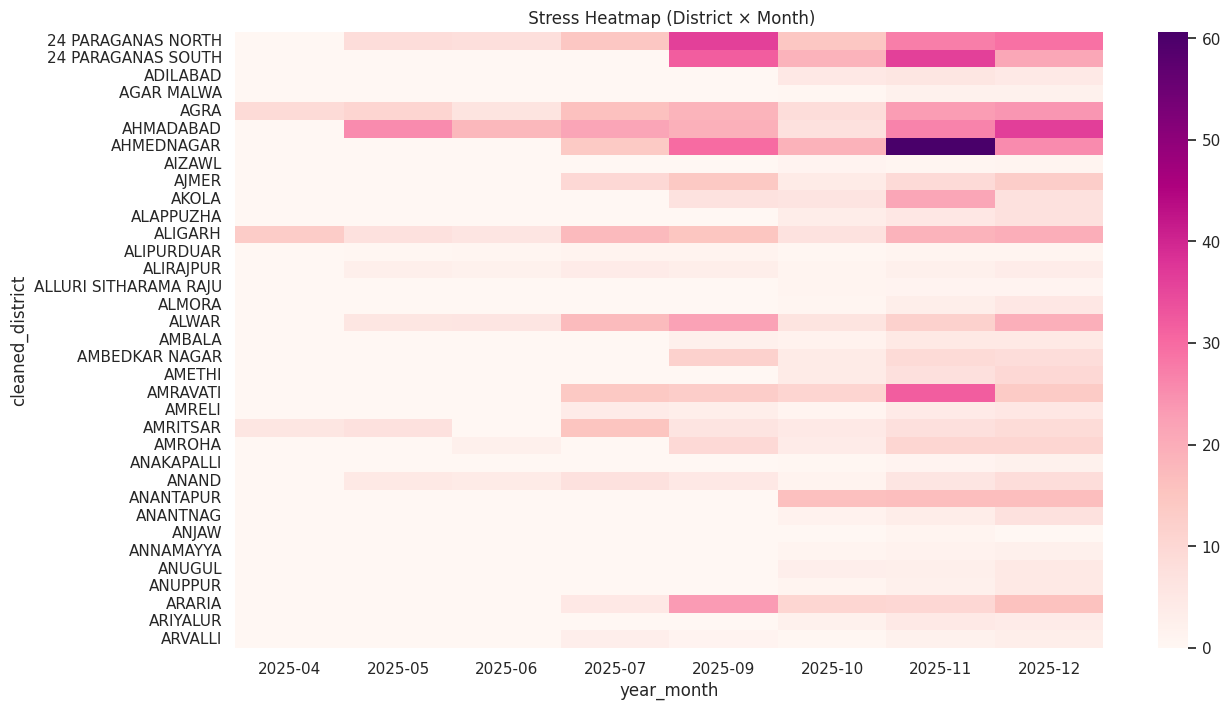

In [ ]:
heat_df = ops_df.pivot_table(
    index="cleaned_district",
    columns="year_month",
    values="stress_index",
    aggfunc="mean"
).fillna(0)

plt.figure(figsize=(14,8))
sns.heatmap(heat_df.head(35), cmap="RdPu")
plt.title(" Stress Heatmap (District × Month)")
plt.show()



* This heatmap shows which districts were under high Aadhaar service stress in which months.

* Darker / stronger color means higher stress, lighter color means low or normal workload.

* We can clearly see that stress is not uniform — it varies across both districts and months.

* A few districts show repeated dark patches across multiple months, meaning they face consistent operational pressure and may need permanent resource support.

* Some districts show only one or two dark months, indicating temporary or seasonal overload (for example, special update/enrolment drives, migration periods, or demand spikes).

* The heatmap helps identify hotspot districts immediately, where workload overload is most likely happening.

* It also helps UIDAI understand when overload peaks, so they can plan staffing and centers in advance.

The stress heatmap provides a clear month-wise and district-wise view of Aadhaar operational pressure. Darker cells highlight periods where specific districts experienced higher workload stress due to increased enrolments and updates, while lighter cells show relatively stable periods. The pattern confirms that service stress is not constant and varies significantly across time. Districts that repeatedly show high stress across months likely require long-term infrastructure or staffing improvements, while districts with isolated peaks may only need temporary support during specific high-demand months. Overall, this visualization supports targeted capacity planning and helps UIDAI proactively manage overload hotspots.

 Chart 3 — Early Warning Alerts Count per Month


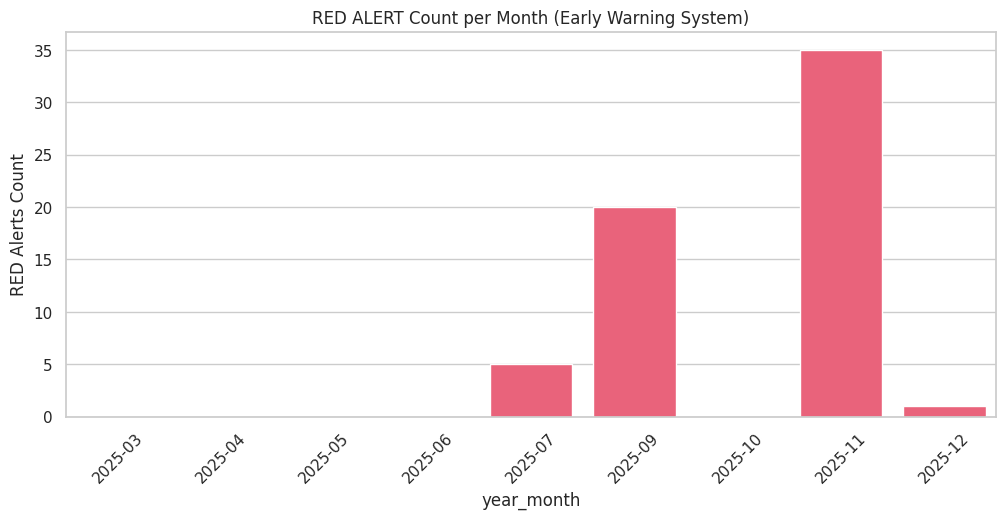

In [ ]:
alert_month = ops_df.groupby("year_month")["early_warning_flag"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=alert_month, x="year_month", y="early_warning_flag", color="#FF4D6D")
plt.xticks(rotation=45)
plt.title("RED ALERT Count per Month (Early Warning System)")
plt.ylabel("RED Alerts Count")
plt.show()


* This chart shows how many RED overload alerts were generated each month.

* A higher bar means more districts crossed overload conditions in that month.

* November 2025 has the highest number of RED alerts, meaning it was the most overloaded month.

* September 2025 also shows a high alert count, indicating another overload peak.

* Some months show very low or zero alerts, which means operations were relatively stable in those months.

* This proves the Early Warning System is useful because it helps UIDAI predict peak overload months and plan resources beforehand.

The RED alert chart highlights the months when Aadhaar service workload crossed critical stress levels across multiple districts. The number of alerts is clearly not uniformANDOM, with strong peaks in November 2025 and September 2025, indicating periods of maximum operational overload. In contrast, several months show very few or no alerts, which suggests stable service load during those periods. Overall, this trend shows that UIDAI can use the alert system to plan staffing, infrastructure, and temporary service capacity before peak months in order to prevent service delays and overcrowding.

Chart 4 — Load vs Growth (Resource Planning Map)


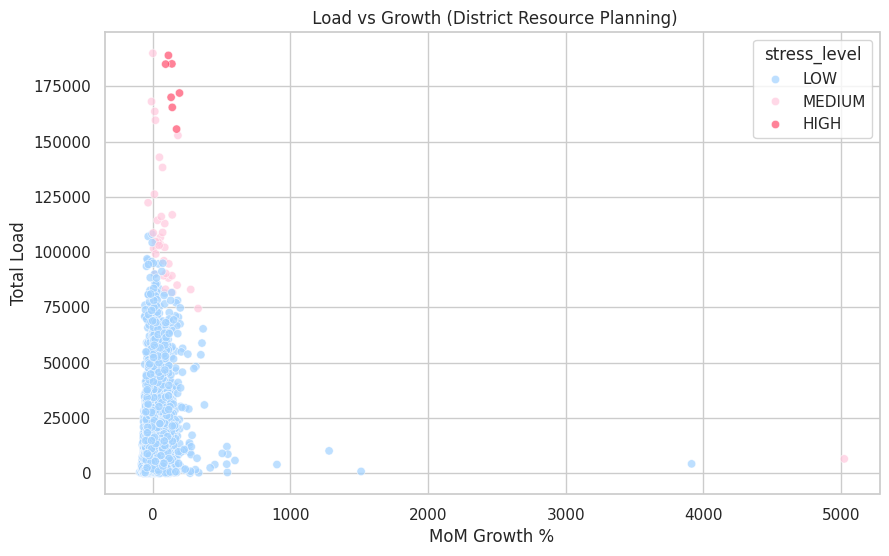

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=ops_df,
    x="load_growth_pct",
    y="total_load",
    hue="stress_level",
    palette={"LOW":"#A2D2FF", "MEDIUM":"#FFC8DD", "HIGH":"#FF4D6D"},
    alpha=0.7
)
plt.title(" Load vs Growth (District Resource Planning)")
plt.xlabel("MoM Growth %")
plt.ylabel("Total Load")
plt.show()


* This chart compares district workload (Total Load) with monthly growth rate (MoM Growth %).

* Each dot is one district-month point.

* High stress (red points) are mostly at high total load, meaning these districts already handle heavy Aadhaar operations.

* Districts in the top-right zone (high load + high growth) indicate urgent overload risk, so UIDAI should deploy extra staff/temporary centres there first.

* Districts with high load but low growth show stable heavy demand — these need permanent infrastructure improvement (more counters/centres).

* Points with very high growth % but low load can be outliers, data noise, or sudden short-term surges, and should be monitored.

The load vs growth chart helps identify which districts need immediate resource support and which require long-term capacity planning. Districts with high total load and high monthly growth represent the most critical cases because demand is increasing rapidly while operations are already heavy. These districts are strong candidates for temporary workforce deployment, additional machines, or extra enrolment/update counters during peak months. On the other hand, districts with high load but relatively low growth show consistent long-term pressure and are better suited for permanent infrastructure expansion. Overall, this visualization provides a clear decision-making map for UIDAI to prioritize resources based on both workload intensity and demand trend.

 Chart 5 — Anomaly Timeline

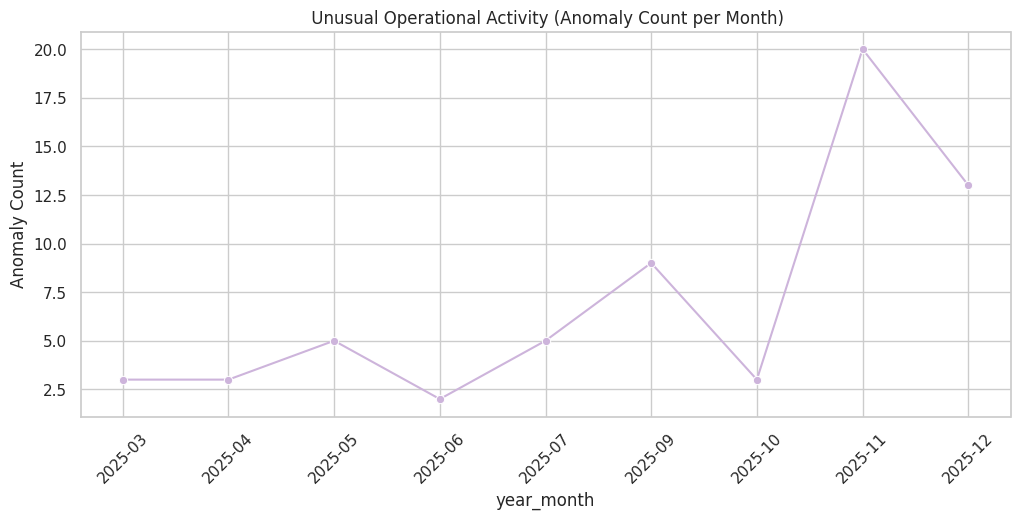

In [ ]:
anom = ops_df.groupby("year_month")["anomaly_flag"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=anom, x="year_month", y="anomaly_flag", marker="o", color="#CDB4DB")
plt.xticks(rotation=45)
plt.title(" Unusual Operational Activity (Anomaly Count per Month)")
plt.ylabel("Anomaly Count")
plt.show()


* This chart shows how many anomaly cases were detected in each month.

* Anomalies mean unusual or unexpected operational activity compared to the normal pattern (not “fraud”, just unusual).

* From March to October 2025, anomaly count stays relatively low and stable, meaning operations were mostly normal.

* A major spike is visible in November 2025, which has the highest anomalies in the entire timeline.

* December 2025 also remains high, showing the unusual activity continued even after November.

* These peak months should be treated as high-priority review periods, because something clearly changed in operations.

The anomaly trend chart highlights months where Aadhaar operations behaved unusually compared to regular trends. Most months show low anomaly counts, indicating stable operational activity across districts. However, November 2025 stands out with a sharp spike, followed by another high count in December 2025. This suggests that during these months, several districts experienced abnormal load patterns, which could be due to sudden demand surges, mass update/enrolment drives, data reporting issues, or operational irregularities. Overall, this chart supports the need for an anomaly monitoring layer so UIDAI can identify such peak months early and perform timely review and corrective action.

Export PowerBI Fact Table

In [ ]:
OUT_DIR = "/content/drive/MyDrive/UIDAI dataset/"
ops_df.to_csv(OUT_DIR + "POWERBI_ops_table.csv", index=False)

alerts_df = ops_df[ops_df["warning_level"] != "NORMAL"].copy()
alerts_df.to_csv(OUT_DIR + "POWERBI_alerts_table.csv", index=False)

anom_df = ops_df[ops_df["anomaly_flag"] == True].copy()
anom_df.to_csv(OUT_DIR + "POWERBI_anomaly_table.csv", index=False)

print("Exported PowerBI CSVs to:", OUT_DIR)


Exported PowerBI CSVs to: /content/drive/MyDrive/UIDAI dataset/


In [ ]:
print("PowerBI ops_df rows:", ops_df.shape[0])
print("Unique districts:", ops_df[['cleaned_state','cleaned_district']].drop_duplicates().shape[0])
print("Unique months:", ops_df['year_month'].nunique())


PowerBI ops_df rows: 3944
Unique districts: 735
Unique months: 9
